In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

np.random.seed(42)
tf.random.set_seed(42)


In [6]:
from google.colab import files

uploaded = files.upload()
fname = list(uploaded.keys())[0]

if fname.endswith(".csv"):
    df = pd.read_csv(fname)
else:
    df = pd.read_excel(fname)

df.head()

Saving S&P500_Financials.xlsx to S&P500_Financials.xlsx


,symbol,quarter,revenue(in billions),grossProfit(in billions),operatingIncome(in billions),netIncome(in billions),eps,ebitda(in billions),totalAssets(in billions),totalLiabilities(in billions),...,totalStockholdersEquity(in billions),netCashProvidedByOperatingActivities(in billions),netCashUsedForInvestingActivites(in billions),netCashUsedProvidedByFinancingActivities(in billions),freeCashFlow(in billions),GDP_Growth,Inflation,Interest_Rate,Unemployment_Rate,SP500_Growth
0,AAPL,2004-03-27,19.09,5.30,0.52,0.46,0.0022,0.98,67.35,22.45,...,44.90,0.61,-4.03,-2.24,0.26,NaN,NaN,NaN,NaN,NaN
1,AAPL,2004-06-26,20.14,5.59,0.72,0.61,0.0029,1.21,72.23,24.11,...,48.12,2.11,-4.60,2.11,1.73,NaN,NaN,NaN,NaN,NaN
2,AAPL,2004-09-25,23.50,6.34,1.28,1.06,0.0049,1.87,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN
3,AAPL,2004-09-30,0.00,0.00,0.00,0.00,NaN,0.00,80.50,29.74,...,50.76,4.43,-7.02,1.08,3.84,0.948594,0.637733,4.303333,5.433333,NaN
4,AAPL,2004-12-25,34.90,9.96,4.03,2.95,0.0134,4.44,93.62,35.72,...,57.90,7.75,-15.23,2.54,7.17,NaN,NaN,NaN,NaN,NaN


In [7]:
# 1) Check symbol column
if "symbol" not in df.columns:
    raise ValueError("Expected a 'symbol' column in the dataset.")

# 2) Symbol → Sector mapping (extend if needed)
sector_map = {
    # Information Technology
    "AAPL": "Information Technology",
    "MSFT": "Information Technology",
    "NVDA": "Information Technology",
    "AVGO": "Information Technology",
    "ADBE": "Information Technology",

    # Communication Services
    "GOOGL": "Communication Services",
    "GOOG":  "Communication Services",
    "META":  "Communication Services",
    "NFLX":  "Communication Services",

    # Consumer Discretionary
    "AMZN": "Consumer Discretionary",
    "TSLA": "Consumer Discretionary",
    "HD":   "Consumer Discretionary",
    "MCD":  "Consumer Discretionary",

    # Financials
    "JPM":  "Financials",
    "BAC":  "Financials",
    "BRK.B":"Financials",
    "BRK.A":"Financials",
    "V":    "Financials",
    "MA":   "Financials",
    "WFC":  "Financials",

    # Health Care
    "UNH":  "Health Care",
    "LLY":  "Health Care",
    "JNJ":  "Health Care",
    "ABBV": "Health Care",
    "PFE":  "Health Care",

    # Consumer Staples
    "PG":   "Consumer Staples",
    "KO":   "Consumer Staples",
    "PEP":  "Consumer Staples",
    "COST": "Consumer Staples",
    "WMT":  "Consumer Staples",

    # Energy
    "XOM": "Energy",
    "CVX": "Energy",
    "COP": "Energy",

    # Industrials (examples)
    "BA":  "Industrials",
    "CAT": "Industrials",
    "GE":  "Industrials",
}

# 3) Create Sector column
df["Sector"] = df["symbol"].map(sector_map).fillna("Other")

print(df[["symbol", "Sector"]].drop_duplicates().head(20))
print("Unique sectors:", df["Sector"].unique())


     symbol                  Sector
0      AAPL  Information Technology
100    AMZN  Consumer Discretionary
184    AVGO  Information Technology
250   BRK-B                   Other
334    GOOG  Communication Services
418   GOOGL  Communication Services
502     JNJ             Health Care
586     JPM              Financials
670     LLY             Health Care
754      MA              Financials
838    META  Communication Services
894    MSFT  Information Technology
978    NFLX  Communication Services
1062   NVDA  Information Technology
1146   ORCL                   Other
1230   PLTR                   Other
1254   TSLA  Consumer Discretionary
1322      V              Financials
1397    WMT        Consumer Staples
1481    XOM                  Energy
Unique sectors: ['Information Technology' 'Consumer Discretionary' 'Other'
 'Communication Services' 'Health Care' 'Financials' 'Consumer Staples'
 'Energy']


In [8]:
TARGET_COL = "freeCashFlow(in billions)"
TIME_COL   = "quarter"   # change if your time column is named differently
SECTOR_COL = "Sector"

feature_cols = [
    "netCashProvidedByOperatingActivities(in billions)",  # micro 1
    "netCashUsedForInvestingActivites(in billions)",      # micro 2
    "cashAndCashEquivalents(in billions)",                # micro 3
    "revenue(in billions)",                               # micro 4
    "operatingIncome(in billions)",                       # micro 5
    "totalLiabilities(in billions)",                      # micro 6
    "totalAssets(in billions)",                           # micro 7
    "GDP_Growth",                                         # macro 1
    "Interest_Rate",                                      # macro 2
    "SP500_Growth",                                       # macro 3
]

cols_needed = [TARGET_COL, SECTOR_COL] + feature_cols
df_q = df.dropna(subset=cols_needed).copy()

print("After cleaning:", df_q.shape)
print("Sectors in cleaned data:", df_q[SECTOR_COL].unique())


After cleaning: (519, 22)
Sectors in cleaned data: ['Information Technology' 'Consumer Discretionary' 'Other'
 'Communication Services' 'Health Care' 'Financials' 'Energy']


Sectors detected for LR: ['Information Technology' 'Consumer Discretionary' 'Other'
 'Communication Services' 'Health Care' 'Financials' 'Energy']

Processing Sector (LR): Information Technology
Rows for Information Technology: 49
✔ LR Metrics for Information Technology: MAE=23.159, RMSE=28.604, R2=0.725


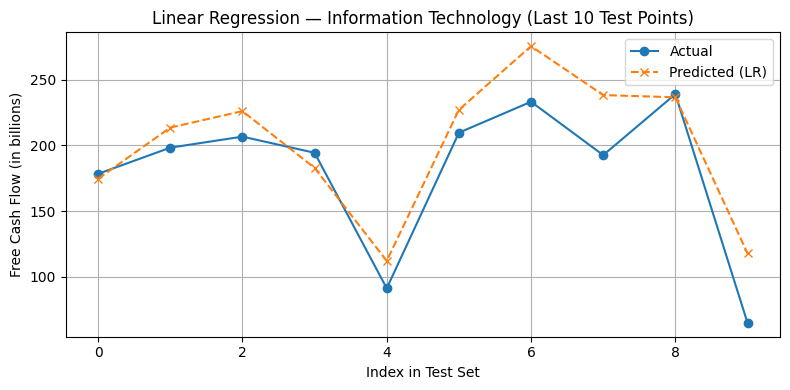


Processing Sector (LR): Consumer Discretionary
Rows for Consumer Discretionary: 72
✔ LR Metrics for Consumer Discretionary: MAE=28.607, RMSE=33.246, R2=0.841


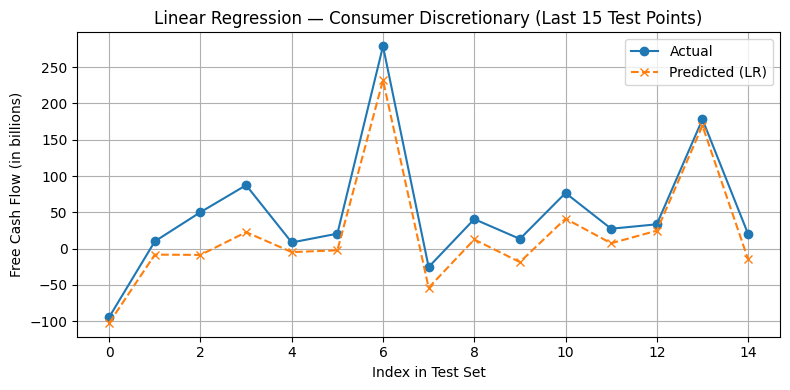


Processing Sector (LR): Other
Rows for Other: 60
✔ LR Metrics for Other: MAE=2.960, RMSE=3.696, R2=0.992


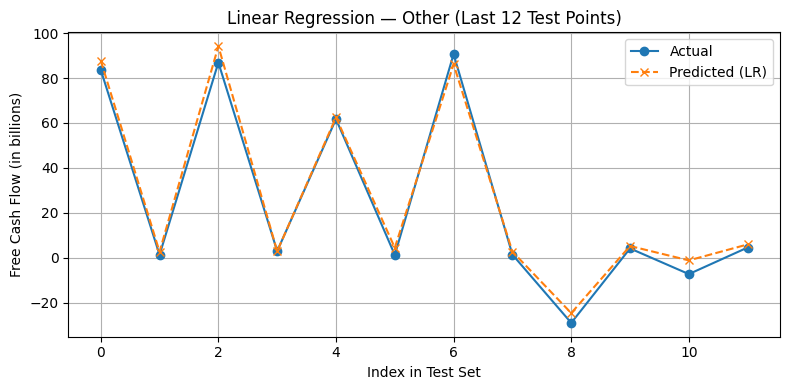


Processing Sector (LR): Communication Services
Rows for Communication Services: 144
✔ LR Metrics for Communication Services: MAE=24.880, RMSE=29.610, R2=0.856


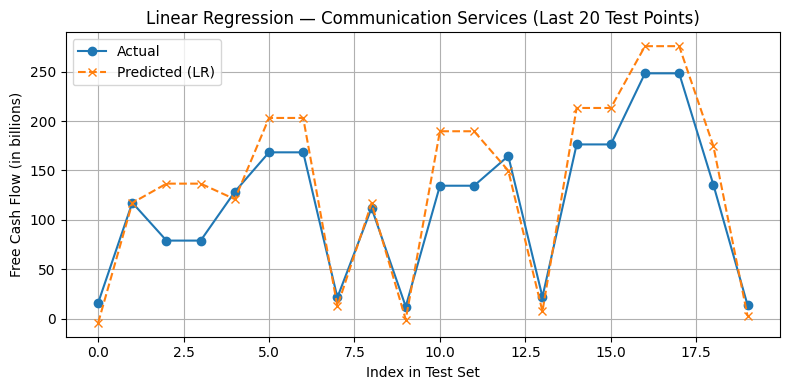


Processing Sector (LR): Health Care
Rows for Health Care: 50
✔ LR Metrics for Health Care: MAE=10.932, RMSE=16.196, R2=0.659


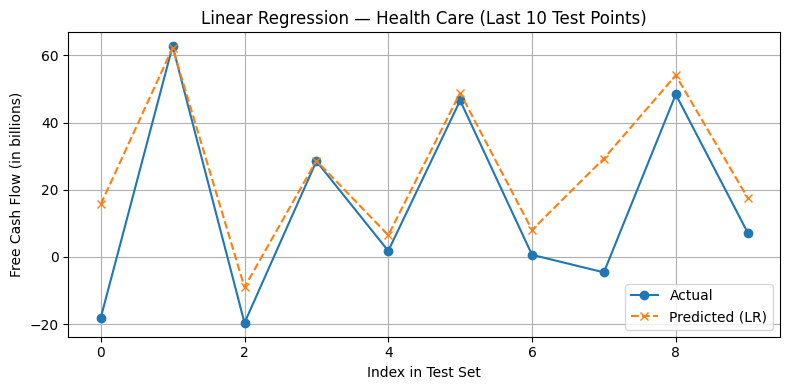


Processing Sector (LR): Financials
Rows for Financials: 108
✔ LR Metrics for Financials: MAE=16.417, RMSE=19.608, R2=0.999


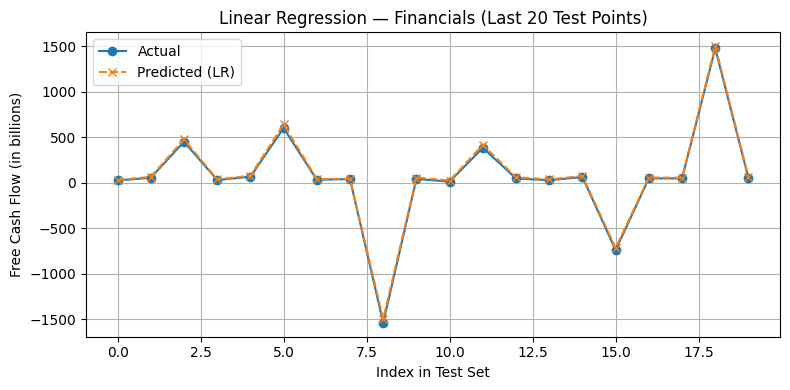


Processing Sector (LR): Energy
Rows for Energy: 36
✔ LR Metrics for Energy: MAE=11.514, RMSE=16.704, R2=0.674


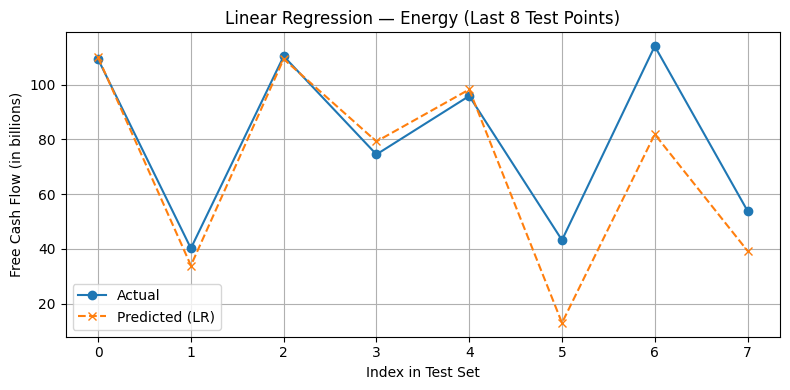

In [10]:
results_lr = []
PLOT_PER_SECTOR = True

sectors = df_q[SECTOR_COL].dropna().unique()
num_features = len(feature_cols)

print("Sectors detected for LR:", sectors)

for sec in sectors:
    print("\n============================")
    print(f"Processing Sector (LR): {sec}")
    print("============================")

    sub = df_q[df_q[SECTOR_COL] == sec].copy()
    n_rows = len(sub)
    print(f"Rows for {sec}: {n_rows}")

    if n_rows < 5:
        print(f"⚠ Sector {sec} has too few rows, skipping.")
        continue

    # Sort by time if present
    if TIME_COL in sub.columns:
        sub = sub.sort_values(TIME_COL)

    X = sub[feature_cols].values
    y = sub[TARGET_COL].values

    # Scale features and target per sector
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaled = X_scaler.fit_transform(X)
    y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

    # 80/20 time-based split
    split_idx = max(1, int(0.8 * len(X_scaled)))
    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]

    if len(X_test) == 0:
        print(f"⚠ No test samples in {sec}, skipping.")
        continue

    # Train Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    # Predict + inverse scale
    y_pred_scaled = lr.predict(X_test)
    y_pred_real = y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
    y_test_real = y_scaler.inverse_transform(y_test.reshape(-1,1)).ravel()

    # Metrics
    mae  = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2   = r2_score(y_test_real, y_pred_real)

    print(f"✔ LR Metrics for {sec}: MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.3f}")

    results_lr.append({
        "Sector": sec,
        "Rows": n_rows,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    # Plot last 20 points
    if PLOT_PER_SECTOR:
        N = min(20, len(y_test_real))
        plt.figure(figsize=(8,4))
        plt.plot(y_test_real[-N:], label="Actual", marker="o")
        plt.plot(y_pred_real[-N:], label="Predicted (LR)", marker="x", linestyle="--")
        plt.title(f"Linear Regression — {sec} (Last {N} Test Points)")
        plt.xlabel("Index in Test Set")
        plt.ylabel("Free Cash Flow (in billions)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [11]:
results_lr_df = pd.DataFrame(results_lr).sort_values("Sector")
results_lr_df

,Sector,Rows,MAE,RMSE,R2
3,Communication Services,144,24.880038,29.609846,0.855954
1,Consumer Discretionary,72,28.607433,33.246004,0.841391
6,Energy,36,11.513910,16.703593,0.673667
5,Financials,108,16.417017,19.607561,0.998812
4,Health Care,50,10.931682,16.196299,0.658935
0,Information Technology,49,23.159364,28.603856,0.724931
2,Other,60,2.959873,3.696378,0.991764
